# DeepSketch — Kaggle Training Notebook
Train a Pix2Pix conditional GAN that converts face photographs into pencil sketches.  
All model, dataset, and training code lives in the repository modules — this notebook only orchestrates execution.

## 1. Check Kaggle GPU & Setup Environment

In [1]:
import os
import torch

os.environ["WANDB_MODE"] = "disabled"
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch Version: 2.9.0+cu126
CUDA Available: True
GPU: Tesla T4


## 2. Clone the GitHub Repository

In [2]:
!rm -rf deep-sketch
!git clone https://github.com/supratimcoder1/deep-sketch.git
%cd deep-sketch

Cloning into 'deep-sketch'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 46 (delta 12), reused 36 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 2.75 MiB | 9.87 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/kaggle/working/deep-sketch


## 3. Install Dependencies

In [3]:
!pip install -r requirements.txt -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 54.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 19.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
a2a-sdk 0.3.23 requires protobuf>=5.29.5, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
ydf 0.14.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.


## 4. Verify Dataset Location

In [4]:
import os

photo_dir = "/kaggle/input/datasets/supratimghosh01/cufs-dataset-clean/dataset/photos"
sketch_dir = "/kaggle/input/datasets/supratimghosh01/cufs-dataset-clean/dataset/sketches"

print("Photos found:", len(os.listdir(photo_dir)))
print("Sketches found:", len(os.listdir(sketch_dir)))

Photos found: 188
Sketches found: 188


## 5. Create Dataset Symlink
Link the Kaggle input dataset into the repo's expected `dataset/` location.

In [5]:
!rm -rf dataset
!mkdir -p dataset
!ln -s /kaggle/input/datasets/supratimghosh01/cufs-dataset-clean/dataset/photos dataset/photos
!ln -s /kaggle/input/datasets/supratimghosh01/cufs-dataset-clean/dataset/sketches dataset/sketches
!ls -la dataset/

print(len(os.listdir("dataset/photos")))
print(len(os.listdir("dataset/sketches")))

total 16
drwxr-xr-x  2 root root 4096 Mar 16 17:40 .
drwxr-xr-x 10 root root 4096 Mar 16 17:40 ..
lrwxrwxrwx  1 root root   72 Mar 16 17:40 photos -> /kaggle/input/datasets/supratimghosh01/cufs-dataset-clean/dataset/photos
lrwxrwxrwx  1 root root   74 Mar 16 17:40 sketches -> /kaggle/input/datasets/supratimghosh01/cufs-dataset-clean/dataset/sketches
188
188


## 6. Start Training

In [ ]:
!python phase1/training/train.py --epochs 350

Using device: cuda
Train samples: 170  |  Val samples: 18
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|█████████████████████████████████████████| 233M/233M [00:01<00:00, 200MB/s]
Loading model from: /usr/loca

## 7. Inspect Training Outputs
Display the latest generated sample images.

Showing: samples/epoch_0350.png


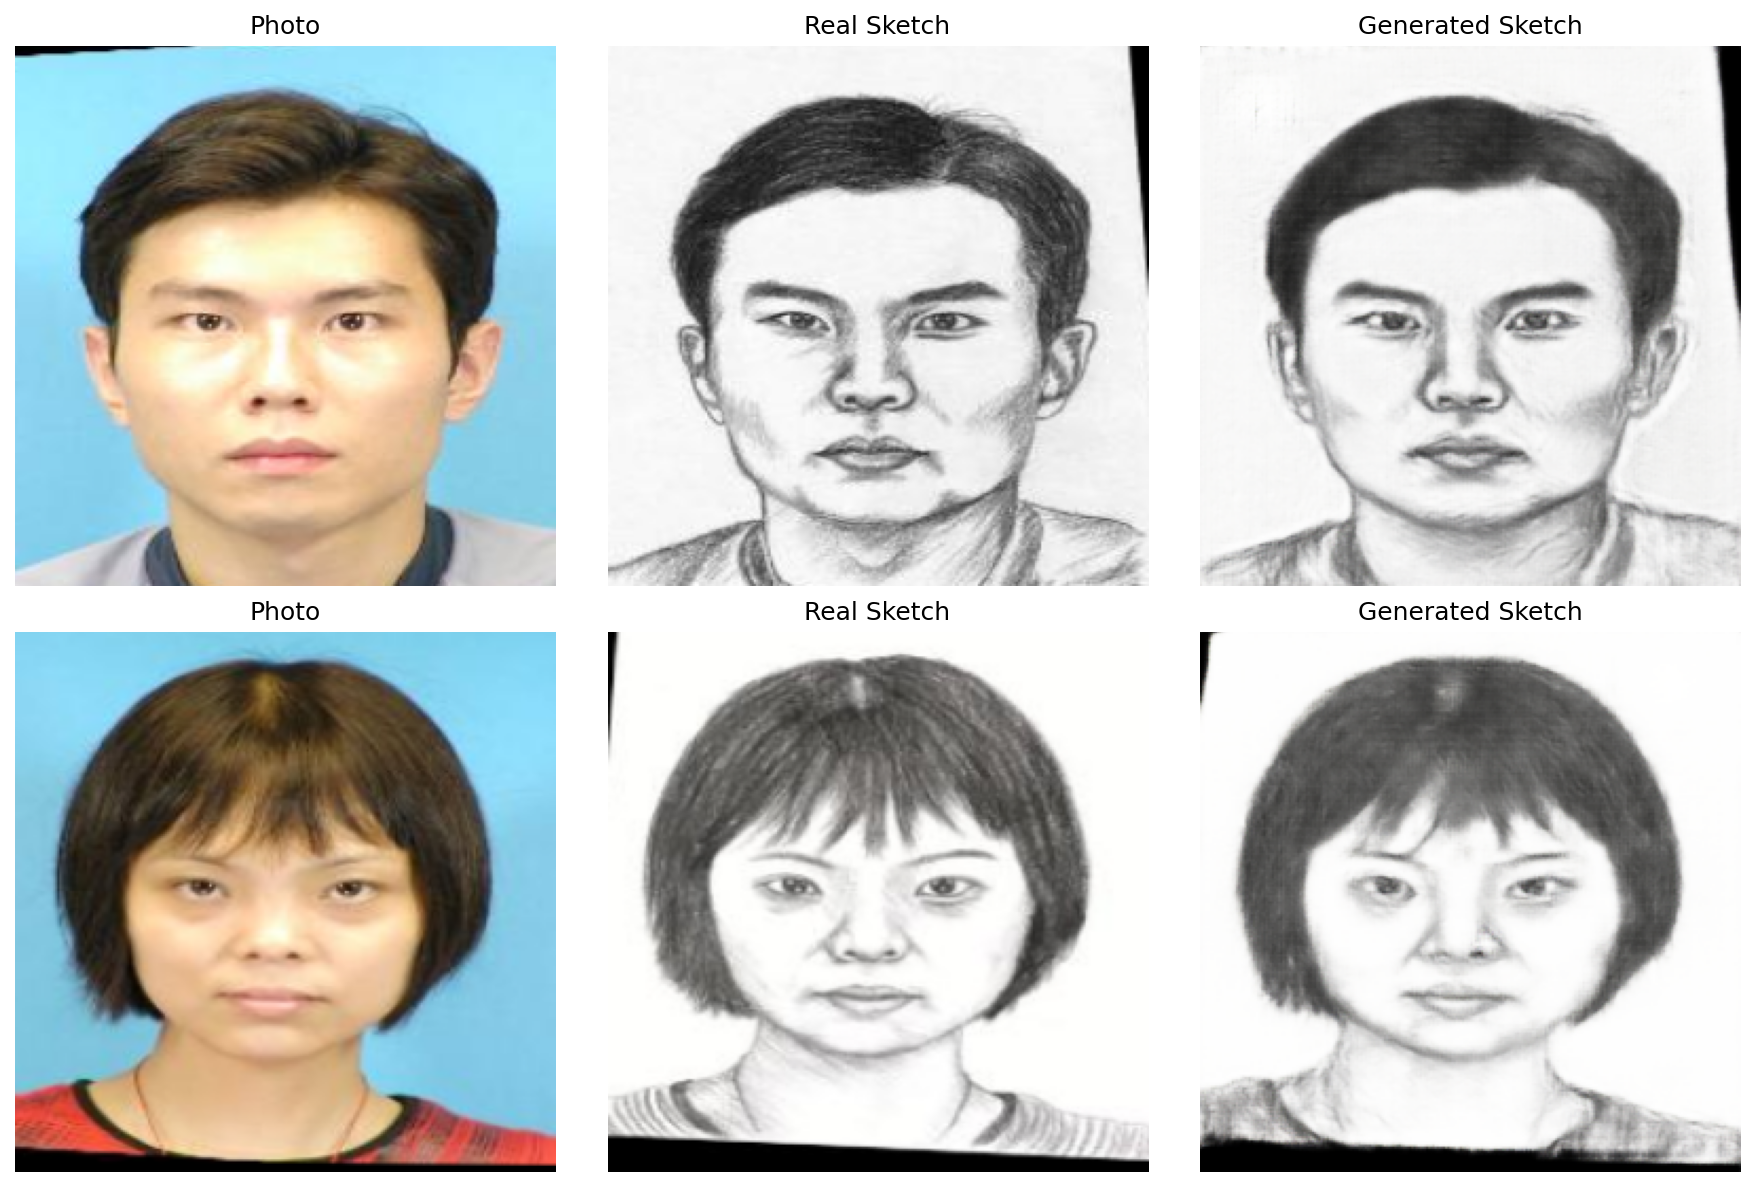

In [7]:
import glob
from IPython.display import display, Image as IPImage

# Find the latest sample image
sample_files = sorted(glob.glob("samples/epoch_*.png"))
if sample_files:
    latest = sample_files[-1]
    print(f"Showing: {latest}")
    display(IPImage(filename=latest, width=800))
else:
    print("No sample images found — training may not have completed.")

## 8. Package Outputs for Download
Zip checkpoints and sample images so they appear in Kaggle's output viewer.

In [ ]:
!zip -r /kaggle/working/deepsketch_bestmodel.zip checkpoints/best_generator.pth
print("Outputs zipped to /kaggle/working/deepsketch_bestmodel.zip")

  adding: checkpoints/best_generator.pth (deflated 7%)
Outputs zipped to /kaggle/working/deepsketch_bestmodel.zip
